# Random Forest

In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

In [2]:
#Loading the prepocessed dataset & Dataset Preview
df = pd.read_csv("../../results/outputs/final_preprocessed_telco_data_new.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nDataset info:")
display(df.info())
print("\nClass distribution:")
print(df['Churn'].value_counts())

Dataset Shape: (7043, 11)

First 5 rows:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Churn
0,-2.839944,-1.247643,1.014425,-0.339953,-1.099294,0.092576,0.517341,0.408477,-0.086671,-0.036771,0
1,-0.352317,1.434602,-0.451466,-0.359328,0.000225,-0.189705,-0.298579,-0.370672,-0.114527,0.056526,0
2,-2.088348,-0.190338,-1.506188,-1.079722,-0.208352,-0.238015,0.160883,-0.210342,0.153532,0.008629,1
3,-0.375654,1.872523,-0.302458,-0.423412,-0.256734,-0.361657,-0.244218,0.374798,0.185815,0.003063,0
4,-1.362409,-2.841712,0.577507,0.012427,0.531640,0.700028,0.178311,-0.106544,0.143042,-0.114418,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     7043 non-null   float64
 1   PC2     7043 non-null   float64
 2   PC3     7043 non-null   float64
 3   PC4     7043 non-null   float64
 4   PC5     7043 non-null   float64
 5   PC6     7043 non-null   float64
 6   PC7     7043 non-null   float64
 7   PC8     7043 non-null   float64
 8   PC9     7043 non-null   float64
 9   PC10    7043 non-null   float64
 10  Churn   7043 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 605.4 KB


None


Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [3]:
# Define features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Variety 1: Basic Random Forest

In [6]:
rf_basic = RandomForestClassifier(random_state=42)
rf_basic.fit(X_train_scaled, y_train)
y_pred_basic = rf_basic.predict(X_test_scaled)

metrics_basic = {
    'accuracy': accuracy_score(y_test, y_pred_basic),
    'precision': precision_score(y_test, y_pred_basic),
    'recall': recall_score(y_test, y_pred_basic),
    'f1_score': f1_score(y_test, y_pred_basic)
}

print(" Random Forest (Basic):")
print(classification_report(y_test, y_pred_basic))


 Random Forest (Basic):
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.59      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.69      1409
weighted avg       0.77      0.78      0.77      1409



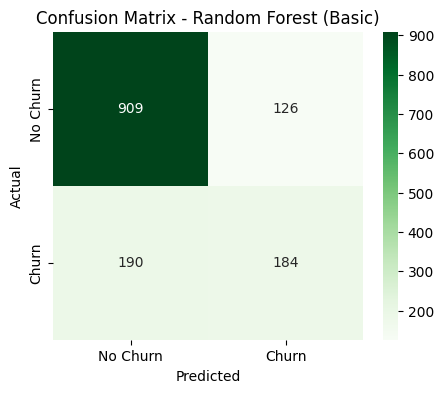

In [7]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_basic), annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
                    
plt.title("Confusion Matrix - Random Forest (Basic)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
#Cross validation 
cv_scores = cross_val_score(rf_basic, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("\nMean CV Accuracy: {:.3f} (+/- {:.3f})".format(cv_scores.mean(), cv_scores.std() * 2))

Cross-Validation Scores: [0.78615794 0.7905945  0.78172138 0.76486247 0.76198934]

Mean CV Accuracy: 0.777 (+/- 0.023)


Variety 2 - Tuned Random Forest (GridSearchCV)

In [9]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

print("\n Tuning Random Forest...")
grid_search.fit(X_train_scaled, y_train)
print("Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

metrics_best = {
    'accuracy': accuracy_score(y_test, y_pred_best),
    'precision': precision_score(y_test, y_pred_best),
    'recall': recall_score(y_test, y_pred_best),
    'f1_score': f1_score(y_test, y_pred_best),
    'best_params': grid_search.best_params_
}

print("\n Random Forest (Best Tuned):")
print(classification_report(y_test, y_pred_best))



 Tuning Random Forest...
Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}

 Random Forest (Best Tuned):
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.56       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409



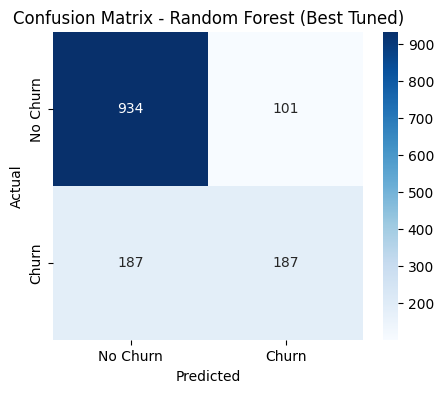

In [10]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title("Confusion Matrix - Random Forest (Best Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
# Cross validation for tuned Random Forest
cv_scores_tuned = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Scores for Tuned Random Forest:", cv_scores_tuned)
print("Mean CV Accuracy: {:.3f} (+/- {:.3f})".format(cv_scores_tuned.mean(), cv_scores_tuned.std() * 2))


Cross-Validation Scores for Tuned Random Forest: [0.81632653 0.80124224 0.7905945  0.77284827 0.77797513]
Mean CV Accuracy: 0.792 (+/- 0.032)


Variety 3 - Random Forest with Class Weight

In [12]:
rf_weighted = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,
    random_state=42
)
rf_weighted.fit(X_train_scaled, y_train)
y_pred_weighted = rf_weighted.predict(X_test_scaled)

metrics_weighted = {
    'accuracy': accuracy_score(y_test, y_pred_weighted),
    'precision': precision_score(y_test, y_pred_weighted),
    'recall': recall_score(y_test, y_pred_weighted),
    'f1_score': f1_score(y_test, y_pred_weighted)
}

print(" Random Forest (Class Weight Balanced):")
print(classification_report(y_test, y_pred_weighted))


 Random Forest (Class Weight Balanced):
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.58      0.46      0.51       374

    accuracy                           0.77      1409
   macro avg       0.70      0.67      0.68      1409
weighted avg       0.75      0.77      0.76      1409



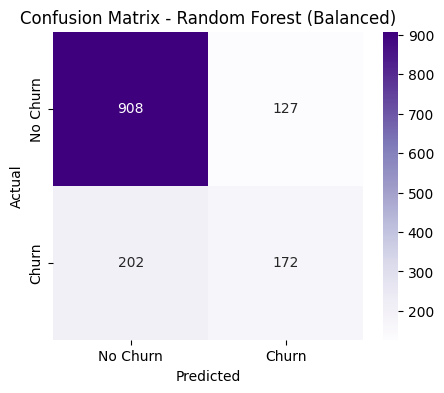

In [13]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_weighted), annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title("Confusion Matrix - Random Forest (Balanced)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
# Cross validation for weighted Random Forest
cv_scores_weighted = cross_val_score(rf_weighted, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Scores for Weighted Random Forest:", cv_scores_weighted)
print("Mean CV Accuracy: {:.3f} (+/- {:.3f})".format(cv_scores_weighted.mean(), cv_scores_weighted.std() * 2))


Cross-Validation Scores for Weighted Random Forest: [0.7905945  0.78704525 0.77905945 0.77284827 0.76554174]
Mean CV Accuracy: 0.779 (+/- 0.018)


comparision

In [15]:
comparison = {
    "Random Forest - Basic": metrics_basic,
    "Random Forest - Tuned": metrics_best,
    "Random Forest - Balanced": metrics_weighted
}

comparison_data = []
for model_name, metrics in comparison.items():
    if 'best_params' in metrics:
        row = {
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1_score'],
            'Best Params': str(metrics['best_params'])[:60] + "..."
        }
    else:
        row = {
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1_score'],
            'Best Params': 'N/A'
        }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.sort_values(by='F1-Score', ascending=False))


,Model,Accuracy,Precision,Recall,F1-Score,Best Params
1,Random Forest - Tuned,0.795600,0.649306,0.500000,0.564955,"{'bootstrap': True, 'max_depth': 10, 'min_samp..."
0,Random Forest - Basic,0.775727,0.593548,0.491979,0.538012,N/A
2,Random Forest - Balanced,0.766501,0.575251,0.459893,0.511144,N/A


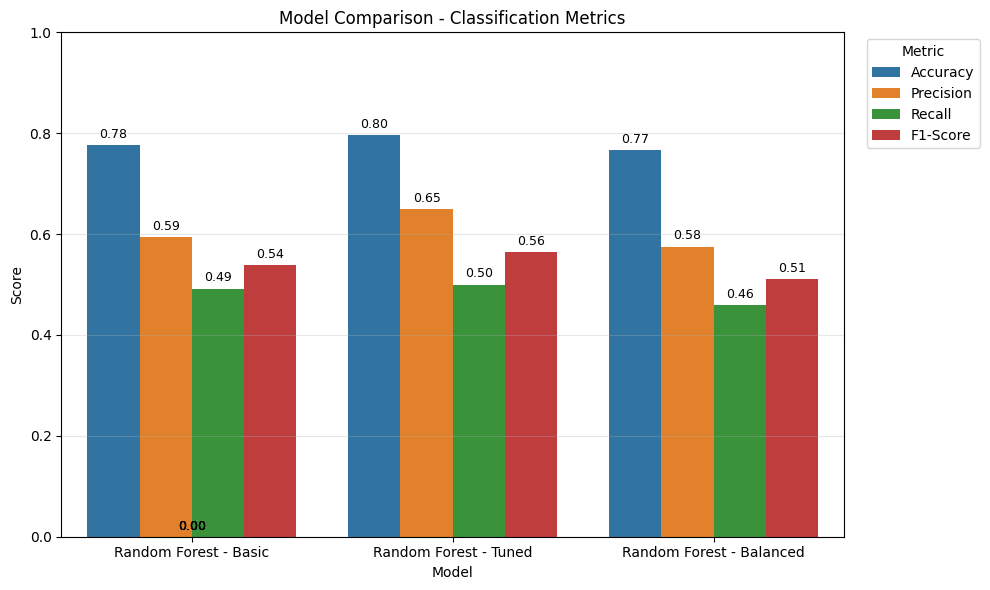

C:\Users\USER\AppData\Local\Temp\ipykernel_6872\4240426788.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=order, x='Model', y='F1-Score', palette='Blues_r')


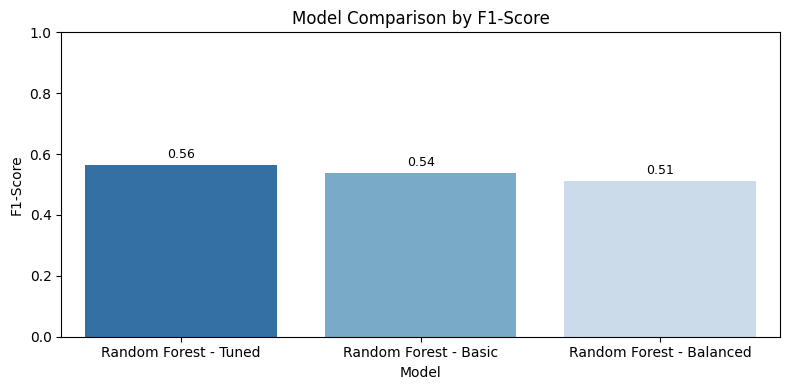

In [16]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
df_melt = comparison_df.melt(
    id_vars='Model',
    value_vars=metrics_to_plot,
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melt, x='Model', y='Score', hue='Metric')
ax.set_title('Model Comparison - Classification Metrics')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_xlabel('Model')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
order = comparison_df.sort_values(by='F1-Score', ascending=False)
ax = sns.barplot(data=order, x='Model', y='F1-Score', palette='Blues_r')
ax.set_title('Model Comparison by F1-Score')
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1-Score')
ax.set_xlabel('Model')
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()